In [1]:
import pennylane as qml
from opt_homo import *
from opt_joint_ego import *
from opt_joint_long import *
from opt_swap import *
from qco_simple import *
from compare_sdk import *
from common_functions import *
from opt_joint_short import *
from opt_cnot_long import *
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
import time

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
[ds] = qml.data.load("ketgpt")

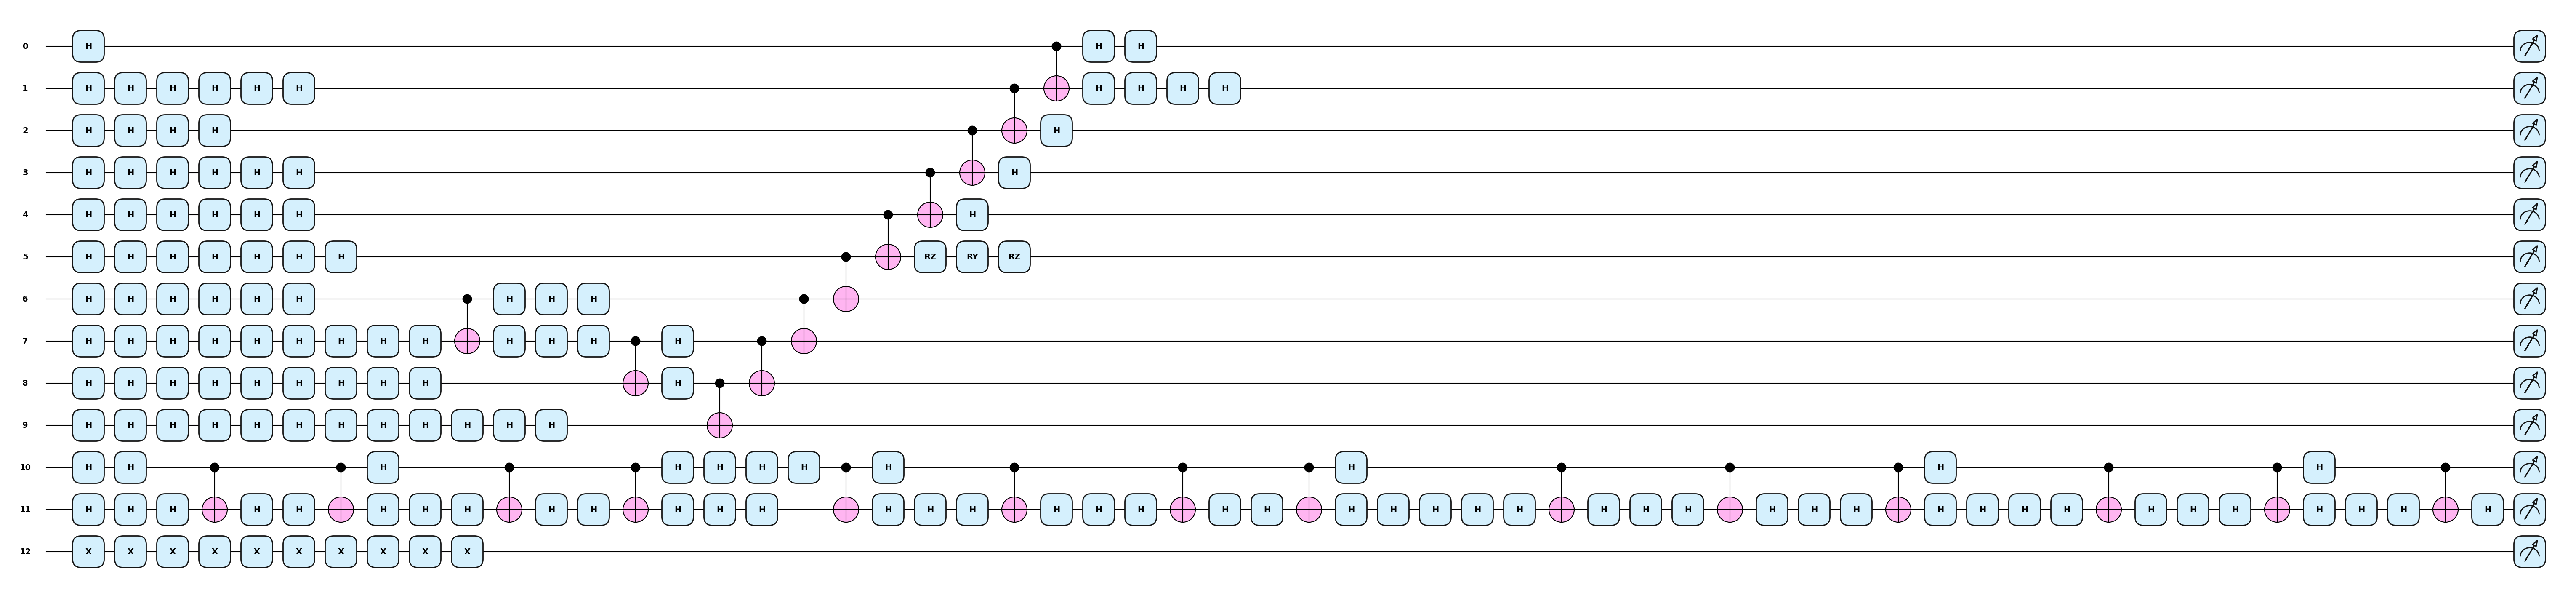

In [3]:
seed = 0
@qml.qnode(qml.device('default.qubit'))
def circuit():
    for op in ds.circuits[seed]:
        name = op.name
        params = op.parameters
        wires = op.wires
        if name == 'QubitUnitary':
            continue
        elif name == 'CZ':
            qml.Hadamard(wires[1])
            qml.CNOT(wires)
            qml.Hadamard(wires[1])
        elif name == 'U1':
            qml.RZ(params[0], wires=wires)
        elif name == 'U2':
            qml.RZ(params[0], wires=wires)
            qml.RY(np.pi/2, wires=wires)
            qml.RZ(params[1], wires=wires)
        else:
            qml.apply(op)
    return qml.state()
show_circuit(circuit)

In [40]:
dataset = []
for s in range(1):
    seed = s
    @qml.qnode(qml.device('default.qubit'))
    def circuit():
        for op in ds.circuits[seed]:
            name = op.name
            params = op.parameters
            wires = op.wires
            if name == 'QubitUnitary':
                continue
            elif name == 'CZ':
                qml.Hadamard(wires[1])
                qml.CNOT(wires)
                qml.Hadamard(wires[1])
            elif name == 'U1':
                qml.RZ(params[0], wires=wires)
            elif name == 'U2':
                qml.RZ(params[0], wires=wires)
                qml.RY(np.pi/2, wires=wires)
                qml.RZ(params[1], wires=wires)
            else:
                qml.apply(op)
        return qml.state()
    circuit_info = extract_info_from_qnode(circuit)
    dataset.append(circuit_info)

In [41]:
def measure_sequence_runtime(sequence, circuit, runs=5):
    runtimes = []
    for _ in range(runs):
        circ_copy = circuit[:]  
        start = time.time()
        for opt in sequence:
            circ_copy = opt(circ_copy)
        end = time.time()
        runtimes.append(end - start)
    return circ_copy, np.mean(runtimes)

In [42]:
class KetGPTEnv(gym.Env):
    def __init__(self, circuit, opt_functions, max_steps, patience, tabu_tenure=5, initial_tabu=None):
        super().__init__()
        self.circuit = circuit
        self.opt_functions = opt_functions
        self.action_space = gym.spaces.Discrete(len(self.opt_functions))
        self.observation_space = gym.spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
        self.max_steps = max_steps
        self.patience = patience
        self.tabu_tenure = tabu_tenure
        self.initial_tabu = initial_tabu or []
        self.current_step = 0
        self.no_change_counter = 0
        self.best_circuit = circuit[:]
        self.best_count = len(circuit)
        self.episode_runtime = 0.0
        self.last_action = -1
        self.action_sequence = []
        self.tabu_list = {}
        self.last_improvement_index = -1

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.no_change_counter = 0
        self.episode_runtime = 0.0
        self.best_circuit = self.circuit[:]
        self.best_count = len(self.circuit)
        self.last_action = -1
        self.action_sequence = []
        self.tabu_list = {}
        self.last_improvement_index = -1
        for func in self.initial_tabu:
            idx = self.opt_functions.index(func)
            self.tabu_list[idx] = self.tabu_tenure
        obs = np.array([len(self.circuit), 0.0, 0.0, -1], dtype=np.float32)
        return obs, {}

    def measure_runtime(self, func, circuit):
        runtimes = []
        for _ in range(5):
            start = time.time()
            _ = func(circuit[:])
            end = time.time()
            runtimes.append(end - start)
        return np.mean(runtimes)

    def step(self, action):
        if isinstance(action, np.ndarray):
            action = int(action.item())
        else:
            action = int(action)

        if action in self.tabu_list and self.tabu_list[action] > 0:
            valid_actions = [i for i in range(len(self.opt_functions)) if self.tabu_list.get(i, 0) == 0]
            if valid_actions:
                action = np.random.choice(valid_actions)

        chosen_func = self.opt_functions[action]
        prev_count = len(self.circuit)

        avg_runtime = self.measure_runtime(chosen_func, self.circuit)
        self.circuit = chosen_func(self.circuit)
        curr_count = len(self.circuit)

        self.episode_runtime += avg_runtime
        self.action_sequence.append(action)
        self.last_action = action

        # update tabu list
        for a in list(self.tabu_list.keys()):
            self.tabu_list[a] = max(0, self.tabu_list[a] - 1)
        self.tabu_list[action] = self.tabu_tenure

        # reward shaping
        reward = -curr_count - 0.1 * self.episode_runtime
        if curr_count < prev_count:
            reward += 5
            self.last_improvement_index = len(self.action_sequence)  # mark last improvement
        if curr_count == prev_count:
            self.no_change_counter += 1
            reward -= 1
        else:
            self.no_change_counter = 0

        obs = np.array([curr_count, self.episode_runtime, self.no_change_counter, action], dtype=np.float32)

        self.current_step += 1
        terminated = False
        truncated = False

        if curr_count < self.best_count:
            self.best_count = curr_count
            self.best_circuit = self.circuit[:]

        if self.no_change_counter >= self.patience:
            terminated = True
        if self.current_step >= self.max_steps:
            truncated = True

        # trim sequence up to last improvement
        if self.last_improvement_index > 0:
            trimmed_seq = self.action_sequence[:self.last_improvement_index]
        else:
            trimmed_seq = self.action_sequence[:]  # keep full if no improvement

        info = {
            "best_circuit": self.best_circuit,
            "best_count": self.best_count,
            "episode_runtime": self.episode_runtime,
            "action_sequence": trimmed_seq
        }
        return obs, reward, terminated, truncated, info

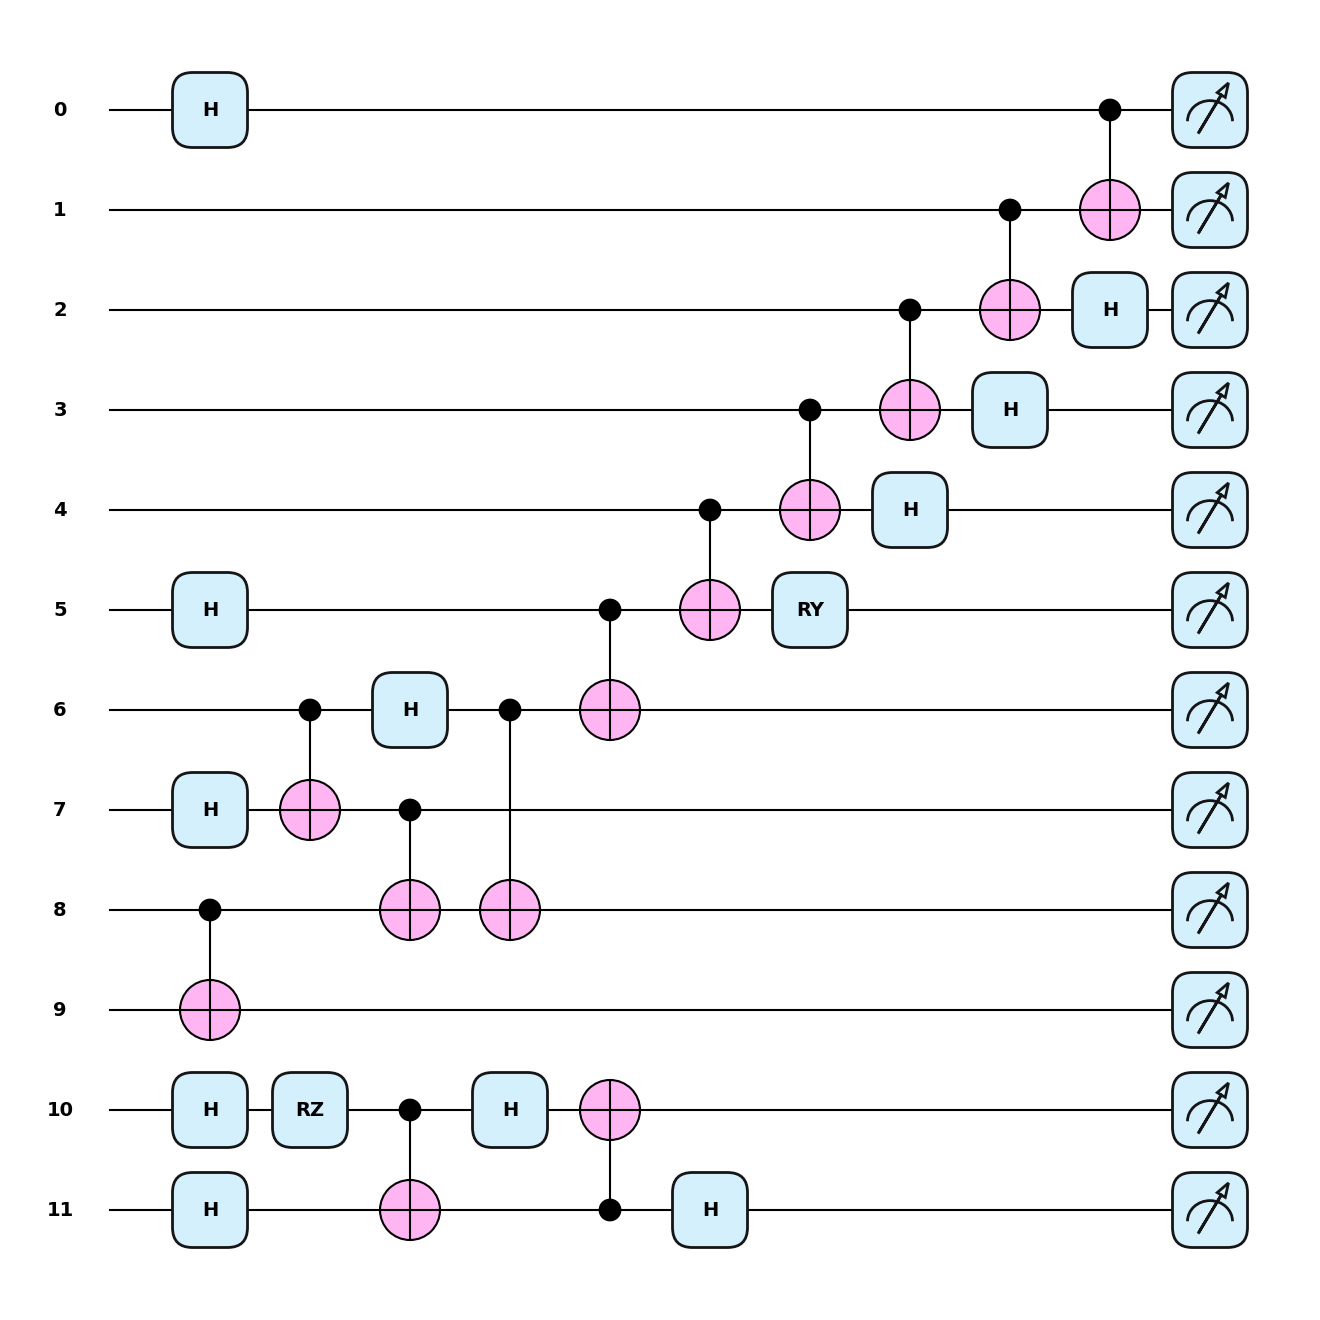

Initial gate count: 173
Best optimized gate count: 25
Episode runtime (s): 0.01607
Best sequence of actions: ['optimizeJointLong', 'singleCommutation', 'optimizeForwardSwap', 'optimizeBackwwardSwap', 'optimizeJointShort', 'cnotSwap', 'optimizeHomo', 'optimizeJointEgo', 'optimizeForwardSwap', 'optimizeJointLong']


In [43]:
circuit_info = dataset[0]

# pre-sequence
seq_prep = [optimizeHomo, optimizeJointEgo, cnotSwap]
circuit_info, runtime_prep = measure_sequence_runtime(seq_prep, circuit_info, runs=5)

opt_functions = [
    optimizeHomo, optimizeJointEgo, optimizeJointShort, optimizeJointLong,
    singleCommutation, cnotSwap, optimizeForwardSwap, optimizeBackwwardSwap,
]

env = KetGPTEnv(
    circuit=circuit_info,
    opt_functions=opt_functions,
    max_steps=50,
    patience=10,
    tabu_tenure=5,
    initial_tabu=[optimizeHomo, optimizeJointEgo, cnotSwap]
)

model = PPO("MlpPolicy", env, ent_coef=0.01, verbose=0, device="cpu")
model.learn(total_timesteps=5000)

# evaluation
obs, info = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

# get results
circuit_info = info["best_circuit"]
best_sequence = [opt_functions[a].__name__ for a in info["action_sequence"]]

# post-sequence
seq_post = [push_long_cnot, phase_removal]
circuit_info, runtime_post = measure_sequence_runtime(seq_post, circuit_info, runs=5)

runtime = round(runtime_prep + info["episode_runtime"] + runtime_post, 5)
show_info(circuit_info)

print("Initial gate count:", len(dataset[0]))
print("Best optimized gate count:", len(circuit_info))
print("Episode runtime (s):", runtime)
print("Best sequence of actions:", best_sequence)

In [44]:
from compare_sdk import comp_table, penny_specs
df = comp_table(circuit)
df['Mine'] = penny_specs(info_to_qnode(circuit_info))
df

,Original,Qiskit,PennyLane,tket,Mine
Gate count,175,31,45,44,25
Single-qubit gate count,150,19,26,33,13
Two-qubit gate count,25,12,19,11,12
Circuit depth,58,14,17,15,10
